# DATASET DISTRIBUTION PLOTS
**Content of the file:** This file includes the code to plot the dataset distribution per label. The plot was done for each task.

### Imports and Paths

In [17]:
import torch
import torch.nn as nn
import os
import numpy as np
import pickle
import pandas as pd
from torch.utils.data import DataLoader, Dataset
from scipy import signal
from sklearn.preprocessing import normalize
from scipy.io import loadmat
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
import math
import scipy as sp
import skimage
import skimage.util
from typing import List,Tuple
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, confusion_matrix


In [18]:
'''## If executing from Google Collab
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH= "/content/drive/Shareddrives/CompBioMed/seminars"'''

'## If executing from Google Collab\nfrom google.colab import drive\ndrive.mount(\'/content/drive\')\n\nBASE_PATH= "/content/drive/Shareddrives/CompBioMed/seminars"'

In [19]:
BASE_PATH = ''

PATH_ALIGNED = os.path.join(BASE_PATH, "outputs", "aligned_qrs.pkl")
PATH_IDENTIFIERS = os.path.join(BASE_PATH, "outputs", "qrs_identifiers.pkl")
PATH_DATA = os.path.join(BASE_PATH, "data", "binary_full_dataset.parquet")

PATH_CARTO = os.path.join(BASE_PATH, "data", "QRS_CARTO2.mat")
PATH_CHINA = os.path.join(BASE_PATH, "data", "QRS_Database2.mat")
PATH_SIMS = os.path.join(BASE_PATH, "data", "QRS_Sims2.mat")

In [20]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'[INFO] Dispositiu: {device.upper()}')

os.makedirs('output/plots', exist_ok=True)

SAMPLE_SIZE = 277 # vull que els agafi tots
N_EPOCHS = 100
RANDOM_STATE = 42
BATCH_SIZE = 16
N_FOLDS = 5

[INFO] Dispositiu: CPU


### Binary Label Distribution
Distributions regarding the binary labels (LVOT-RVOT)

In [21]:

def load_teknon():
    print('\n-- Loading Teknon ------------------------------------------')
    with open(PATH_ALIGNED, 'rb') as f:
        aligned_ecgs = pickle.load(f)
    X_teknon_all = np.array(aligned_ecgs, dtype=np.float32)
    X_teknon_all = np.transpose(X_teknon_all, (0, 2, 1))

    with open(PATH_IDENTIFIERS, 'rb') as f:
        df_id = pickle.load(f)

    df_full  = pd.read_parquet(PATH_DATA)
    Y_tabular = df_full['Chamber_Type']

    indices_comuns = df_id.index.intersection(Y_tabular.index)
    print(f'  ECGs en pipeline        : {len(df_id)}')
    print(f'  Pacientes en parquet    : {len(Y_tabular)}')
    print(f'  Pacientes sincronizados : {len(indices_comuns)}')

    y_raw        = Y_tabular.loc[indices_comuns].values
    posicions_ecg = [df_id.index.get_loc(idx) for idx in indices_comuns]
    X_tek        = X_teknon_all[posicions_ecg]

    mapping = {'LV': 0, 'RV': 1}
    y_tek   = np.array([mapping[v] if v in mapping else int(v) for v in y_raw],
                       dtype=np.int64)

    print(f'  Shape ECGs              : {X_tek.shape}')
    print(f'  LV (0): {(y_tek==0).sum()}   RV (1): {(y_tek==1).sum()}')
    return X_tek, y_tek

X_teknon, y_teknon = load_teknon()


-- Loading Teknon ------------------------------------------
  ECGs en pipeline        : 178
  Pacientes en parquet    : 180
  Pacientes sincronizados : 177
  Shape ECGs              : (177, 12, 277)
  LV (0): 74   RV (1): 103


In [ ]:
def _build_binary_target(dSim, data_key):
    mapping  = {'LV': 0, 'RV': 1}
    # Check for structural typos in the dataset structured array field names
    key_name = ('LeftRight' if 'LeftRight' in dSim[data_key].dtype.names
                else 'LeftRigth')
    raw_labels = dSim[data_key][key_name]
    y = np.zeros(len(raw_labels[0]), dtype=np.int64)
    for i, label in enumerate(raw_labels[0]):
        y[i] = mapping[label[0]]
    return y


def _handle_sublocation(dSim: dict,
                        data_key: str,
                        path: str,
                        X: np.ndarray,
                        y: np.ndarray) -> (np.ndarray, np.ndarray, np.ndarray):
    """
    Unified and tolerant version that maps sublocations while ensuring that 
    no patient sample is dropped during comparative plot generation.
    """
    mapping = {
        'LCC': 0, 'RCC': 1, 'COMMISSURE': 2, 'LVOT Subvalvular': 3,
        'LVOT Summit': 4, 'RVOT Septum': 5, 'RFW': 6, 'Generic/Unknown': 7
    }

    raw_labels = dSim[data_key]["Sublocation"]
    y_sub = []
    valid_indices = []

    for i, label in enumerate(raw_labels[0]):
        try:
            # If the label is empty or null, check the binary target to classify it generically
            if len(label) == 0:
                label_str = 'Generic/Unknown'
            else:
                label_str = str(label[0]).strip()

            # Normalize synonyms exactly as done in the training pipeline
            if label_str in ['LCCRCC', 'LCC-RCC']:
                label_str = 'COMMISSURE'
            elif label_str in ['Posteroseptal', 'Anteroseptal']:
                label_str = 'RVOT Septum'
            elif label_str == "AMC":
                label_str = 'LVOT Subvalvular'
            elif label_str == "Summit":
                label_str = 'LVOT Summit'
            elif label_str in ["RV", "-", "RVOTOther", "Undefined"]:
                # Instead of discarding, check the binary value for a broad classification
                if y[i] == 0:
                    label_str = 'LVOT Subvalvular'  # Conservative left side assignment
                else:
                    label_str = 'Generic/Unknown'

            # Assign to the final numerical vector
            if label_str in mapping:
                y_sub.append(mapping[label_str])
            else:
                y_sub.append(mapping['Generic/Unknown'])
            
            valid_indices.append(i)

        except Exception as e:
            # In case of a critical parsing error, assign the generic class to safeguard the patient count
            y_sub.append(mapping['Generic/Unknown'])
            valid_indices.append(i)

    X = X[valid_indices]
    y = y[valid_indices]
    y_sub = np.array(y_sub, dtype=np.int64)

    return X, y, y_sub

In [23]:

def _load_mat_dataset(path, sample_size, data_key, lead_names, sublocation):
    dSim = loadmat(path)
    n_patients = dSim[data_key][lead_names[0]].shape[1]
    print(f"Number of patients in file: {n_patients}")

    X = np.zeros((n_patients, len(lead_names), sample_size))

    # Inicialize y_sub as None if sublocation=False
    y_sub = None

    for iLead, lead in enumerate(lead_names):
        lead_data = dSim[data_key][lead]
        for i in range(n_patients):
            patient_signal = lead_data[0, i]
            signal_1d = np.asarray(patient_signal).squeeze()

            if signal_1d.ndim != 1:
                continue

            resampled = signal.resample(signal_1d, sample_size)

            if np.max(np.abs(resampled)) > 0:
                resampled = resampled / np.max(np.abs(resampled))

            X[i, iLead, :] = resampled

    y = _build_binary_target(dSim, data_key)

    if sublocation:
        
        X, y, y_sub = _handle_sublocation(dSim, data_key, path, X, y)

    return {
        "data": X,
        "target": y,
        "subtarget": y_sub
    }

def load_dataset(path: str,
                 sample_size: int,
                 data_key: str,
                 lead_names: list = None,
                 sublocation: bool = False,
                 shuffle: bool = True,
                 random_state: int = None):

    if lead_names is None:
        lead_names = ["I","II","III","aVR","aVL","aVF",
                      "V1","V2","V3","V4","V5","V6"]

    print(f"\n--- Loading dataset from: {path} ---")

    DB_dict = _load_mat_dataset(path, sample_size=sample_size, data_key=data_key,
                                lead_names=lead_names, sublocation=sublocation)

    X = DB_dict["data"]
    y = DB_dict["target"]
    y_sub = DB_dict["subtarget"]

    # Shuffling conjunt (including y_sub if exists)
    if shuffle:
        rng = np.random.default_rng(random_state)
        indices = rng.permutation(len(X))
        X = X[indices]
        y = y[indices]
        if y_sub is not None:
            y_sub = y_sub[indices]

    if sublocation:
        return X, y, y_sub
    return X, y


SAMPLE_SIZE = 277

X_Sims, y_Sims, y_sub_Sims = load_dataset(PATH_SIMS, sample_size=SAMPLE_SIZE, data_key='QRS_Sims', sublocation=True, shuffle=False)
X_China, y_China, y_sub_China = load_dataset(PATH_CHINA, sample_size=SAMPLE_SIZE, data_key='QRS', sublocation=True, shuffle=False)
X_Clinic, y_Clinic, y_sub_Clinic = load_dataset(PATH_CARTO, sample_size=SAMPLE_SIZE, data_key='QRS_CARTO', sublocation=True, shuffle=False)


--- Loading dataset from: data\QRS_Sims2.mat ---


Number of patients in file: 2496

--- Loading dataset from: data\QRS_Database2.mat ---
Number of patients in file: 333

--- Loading dataset from: data\QRS_CARTO2.mat ---
Number of patients in file: 43


In [24]:
# Inverse mapping dictionaries to display categorical names instead of indices
map_binary = {0: "LV (Left)", 1: "RV (Right)"}
map_sub = {
    0: 'LCC', 1: 'RCC', 2: 'COMMISSURE', 3: 'LVOT Subvalvular',
    4: 'LVOT Summit', 5: 'RVOT Septum', 6: 'RFW (RVOT Free Wall)', 7: 'Generic/Unknown'
}

datasets = {
    "Simulations (Sims)": (y_Sims, y_sub_Sims),
    "China (Database2)": (y_China, y_sub_China),
    "Clinic (CARTO2)": (y_Clinic, y_sub_Clinic)
}

for name, (y, y_sub) in datasets.items():
    print(f"\n==========================================")
    print(f" DATASET STATISTICS: {name.upper()}")
    print(f"==========================================")
    print(f"Total final valid patients: {len(y)}")

    # Site of Origin Counting (Binary Target)
    print("\n  • Binary Target (Site of Origin):")
    vals_b, counts_b = np.unique(y, return_counts=True)
    for v, c in zip(vals_b, counts_b):
        label_name = map_binary.get(v, f"Unknown ({v})")
        print(f"    - {label_name:<15}: {c} patients ({c/len(y)*100:.1f}%)")

    # Detailed Sublocations Counting
    if y_sub is not None:
        print("\n  • Detailed Sublocations:")
        vals_s, counts_s = np.unique(y_sub, return_counts=True)
        for v, c in zip(vals_s, counts_s):
            sub_name = map_sub.get(v, f"Unknown ({v})")
            print(f"    - [{v}] {sub_name:<22}: {c} patients")
    else:
        print("\n  • Sublocations: Not available.")


 DATASET STATISTICS: SIMULATIONS (SIMS)
Total final valid patients: 2496

  • Binary Target (Site of Origin):
    - LV (Left)      : 1456 patients (58.3%)
    - RV (Right)     : 1040 patients (41.7%)

  • Detailed Sublocations:
    - [0] LCC                   : 416 patients
    - [1] RCC                   : 416 patients
    - [2] COMMISSURE            : 208 patients
    - [3] LVOT Subvalvular      : 208 patients
    - [4] LVOT Summit           : 208 patients
    - [5] RVOT Septum           : 832 patients
    - [6] RFW (RVOT Free Wall)  : 208 patients

 DATASET STATISTICS: CHINA (DATABASE2)
Total final valid patients: 333

  • Binary Target (Site of Origin):
    - LV (Left)      : 77 patients (23.1%)
    - RV (Right)     : 256 patients (76.9%)

  • Detailed Sublocations:
    - [0] LCC                   : 39 patients
    - [1] RCC                   : 7 patients
    - [2] COMMISSURE            : 7 patients
    - [3] LVOT Subvalvular      : 19 patients
    - [4] LVOT Summit           : 5 

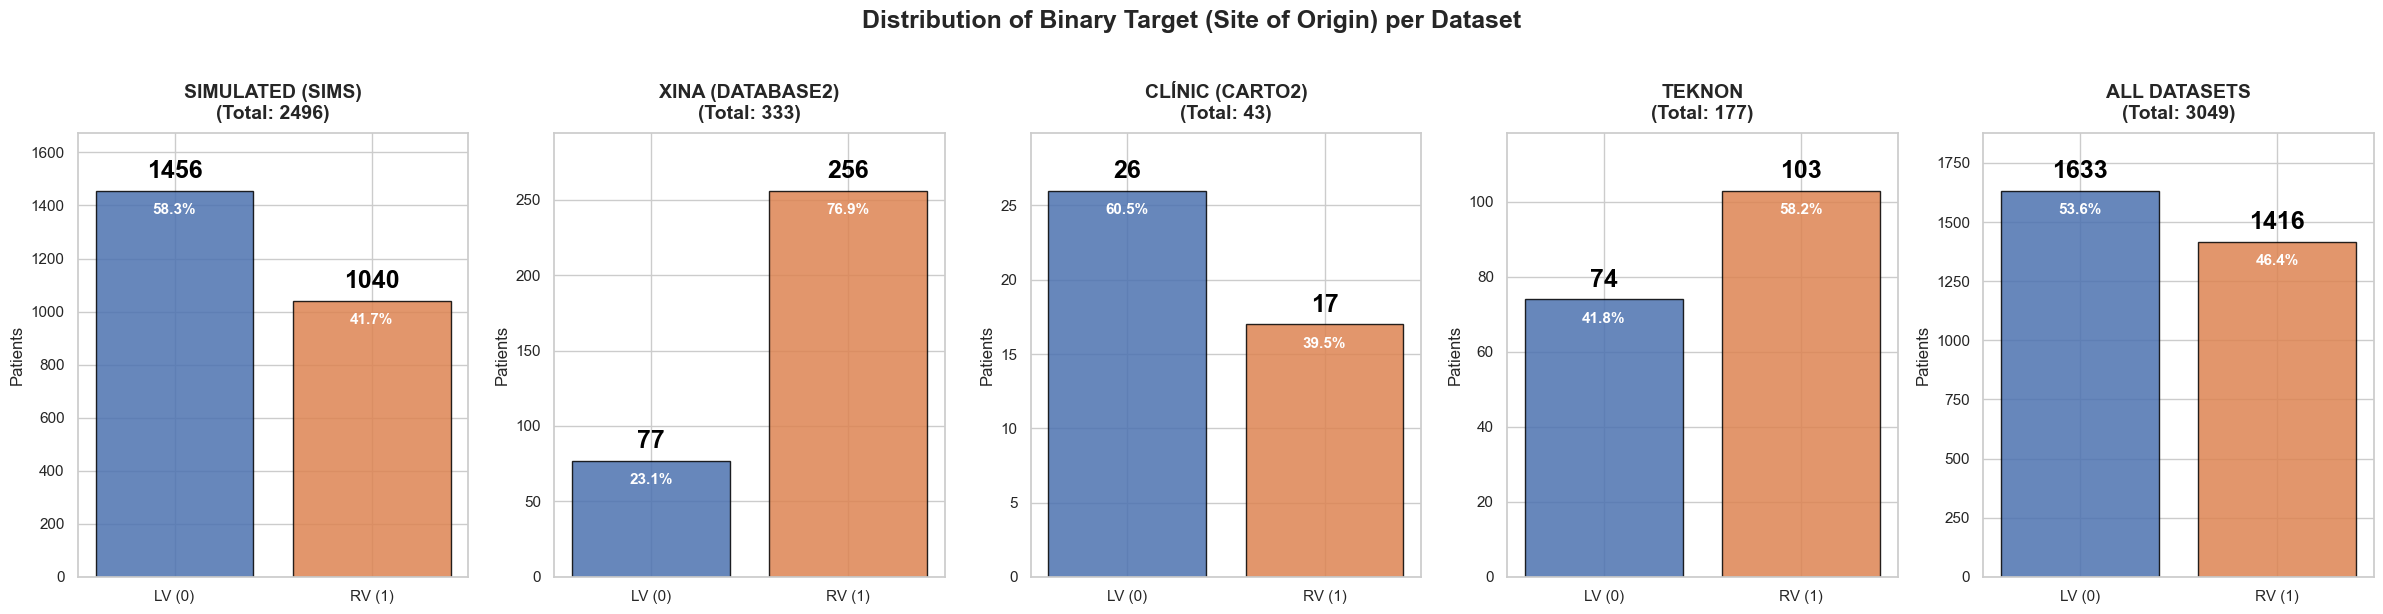

In [25]:
# Display the statistics

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 5, figsize=(24, 6), sharey=False)
fig.suptitle('Distribution of Binary Target (Site of Origin) per Dataset', fontsize=18, fontweight='bold', y=1.02)

# Mapping for x-axis
labels = ['LV (0)', 'RV (1)']
colors = ['#4C72B0', '#DD8452'] 

datasets_plot = {
    "Simulated (Sims)": y_Sims,
    "Xina (Database2)": y_China,
    "Clínic (CARTO2)": y_Clinic,
    "Teknon": y_teknon,
    "All datasets": np.concatenate([y_Sims, y_China, y_Clinic, y_teknon])
}

for i, (name, y_data) in enumerate(datasets_plot.items()):
    ax = axes[i]

    vals, counts = np.unique(y_data, return_counts=True)

    counts_dict = dict(zip(vals, counts))
    final_counts = [counts_dict.get(0, 0), counts_dict.get(1, 0)]
    total = sum(final_counts)

    # Create bar plot
    bars = ax.bar(labels, final_counts, color=colors, edgecolor='black', alpha=0.85, width=0.8)

    # Title and axis configuration
    ax.set_title(f"{name.upper()}\n(Total: {total})", fontsize=14, fontweight='bold', pad=10)
    ax.set_ylabel('Patients', fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=11)

    ax.set_ylim(0, max(final_counts) * 1.15)

    # Add numbers and percentages
    for bar in bars:
        height = bar.get_height()
        percentage = (height / total) * 100

        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height + (max(final_counts) * 0.02),
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=18,
            fontweight='bold',
            color='black'
        )

        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height - (max(final_counts) * 0.05) if height > (max(final_counts) * 0.1) else height + (max(final_counts) * 0.08),
            f'{percentage:.1f}%',
            ha='center',
            va='center',
            fontsize=11,
            fontweight='semibold',
            color='white' if height > (max(final_counts) * 0.1) else 'black'
        )

plt.tight_layout()
os.makedirs('output/plots', exist_ok=True)
plt.savefig('output/plots/dataset_binary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Multilabel Distribution
The distribution regarding the 7 sublocations

In [26]:
# ── CODE BLOCK TO EXTRACT MULTILABEL SUBLOCATIONS FOR TEKNON ─────────────────

PATH_TABULAR_PARQUET = os.path.join(BASE_PATH, "data", "multiclass_full_dataset.parquet")
print("Loading Teknon signals and identifiers...")
with open(PATH_ALIGNED, 'rb') as f:
    aligned_ecgs = pickle.load(f)

with open(PATH_IDENTIFIERS, 'rb') as f:
    df_id = pickle.load(f)

X_teknon_all = np.array(aligned_ecgs, dtype=np.float32)
if X_teknon_all.shape[1] == 277:
    X_teknon_all = np.transpose(X_teknon_all, (0, 2, 1))

print("Loading Teknon clinical data...")
df_clinics = pd.read_parquet(PATH_TABULAR_PARQUET)

# Drop raw signal lead column series if they are present in the dataframe
LEAD_COLS = ['I','II','III','AVR','AVL','AVF','V1','V2','V3','V4','V5','V6']
df_clinics = df_clinics.drop(columns=LEAD_COLS, errors='ignore')

if 'patient_id' in df_clinics.columns:
    df_clinics = df_clinics.set_index('patient_id')

TARGET_COL = 'Final_Label'

# Strict mapping dictionary to integer indices based on raw textual labels
CLASS_MAPPING = {
    'LCC': 0,
    'RCC': 1,
    'COMMISSURE': 2,
    'LVOTSUBVALVULAR': 3,
    'LVOTSUMMIT': 4,
    'RVOTSEPTUM': 5, 'SEPTUM': 5,
    'RVOTFREEWALL': 6, 'RFW': 6
}

# Text normalization and categorical numerical mapping
df_clinics[TARGET_COL] = df_clinics[TARGET_COL].astype(str).str.strip().str.upper()
df_clinics[TARGET_COL] = df_clinics[TARGET_COL].map(CLASS_MAPPING)
df_clinics = df_clinics.dropna(subset=[TARGET_COL])

# Strict sample synchronization between tracking identifier rows and clinical data
indices_comuns = df_id.index.intersection(df_clinics.index)
print(f"DEBUG: Coinciding patients: {len(indices_comuns)}")

if len(indices_comuns) == 0:
    raise ValueError("⚠️ CRITICAL ERROR: No patient matching found.")

# Final array index sorting and clinical dataframe filtering slice
df_clinics = df_clinics.loc[indices_comuns].copy()

# EXTRACTING THE MULTICLASS TARGET VECTOR LABELS
y_tek = df_clinics[TARGET_COL].values.astype(np.int64)

Loading Teknon signals and identifiers...
Loading Teknon clinical data...
DEBUG: Coinciding patients: 176


 MULTICLASS TARGET SUBLOCATION DISTRIBUTIONS PER DATASET

DATASET: SIMULATED (SIMS) (Total patients: 2496)
  • LCC               :  416 patients ( 16.7%)
  • RCC               :  416 patients ( 16.7%)
  • COMMISSURE        :  208 patients (  8.3%)
  • LVOT Subvalvular  :  208 patients (  8.3%)
  • LVOT Summit       :  208 patients (  8.3%)
  • RVOT Septum       :  832 patients ( 33.3%)
  • RVOT Free Wall    :  208 patients (  8.3%)

DATASET: CHINA (DATABASE2) (Total patients: 288)
  • LCC               :   39 patients ( 13.5%)
  • RCC               :    7 patients (  2.4%)
  • COMMISSURE        :    7 patients (  2.4%)
  • LVOT Subvalvular  :   19 patients (  6.6%)
  • LVOT Summit       :    5 patients (  1.7%)
  • RVOT Septum       :  131 patients ( 45.5%)
  • RVOT Free Wall    :   80 patients ( 27.8%)

DATASET: CLINIC (CARTO2) (Total patients: 21)
  • LCC               :    8 patients ( 38.1%)
  • RCC               :    8 patients ( 38.1%)
  • COMMISSURE        :    5 patients ( 23.8

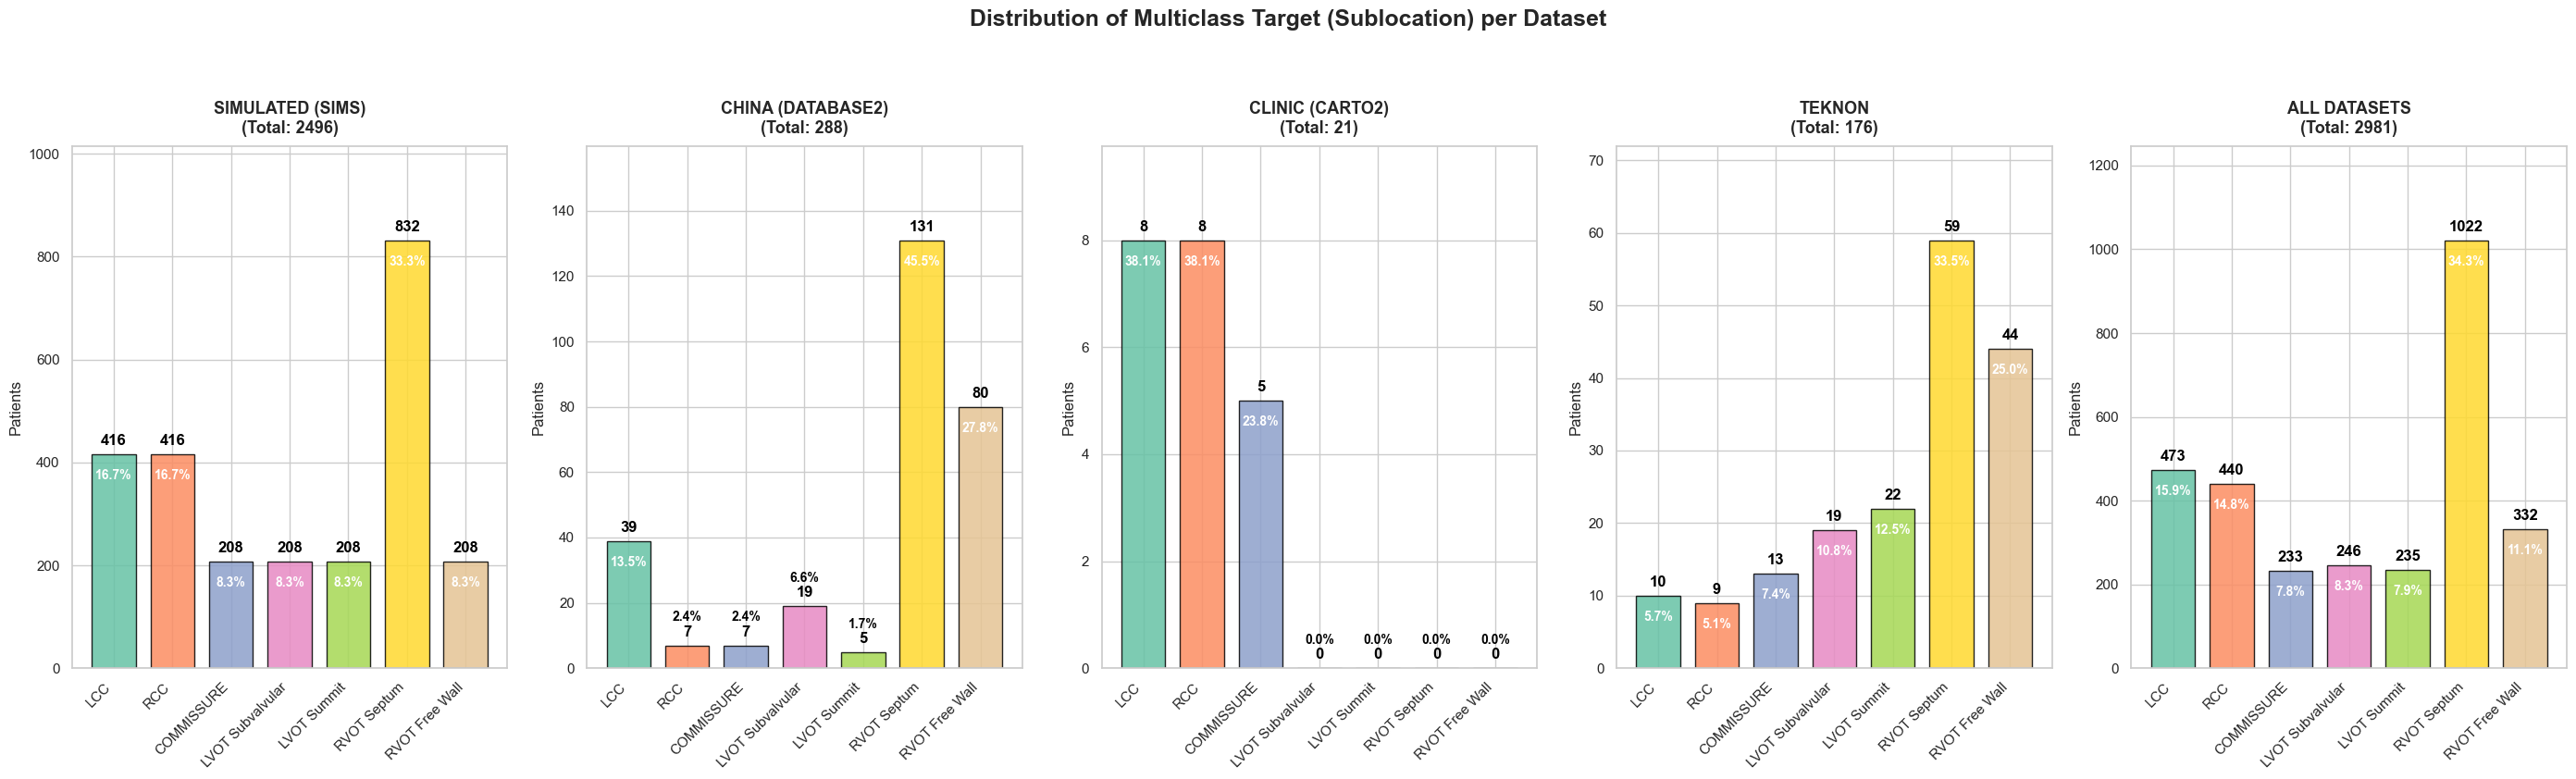

In [27]:
# ── CODE BLOCK TO EXTRACT AND PLOT MULTICLASS SUBLOCATION DISTRIBUTIONS ──────

# Configure Seaborn visual theme
sns.set_theme(style="whitegrid")

# Strict array sequence naming definitions for categorical class mappings
CLASS_NAMES = ['LCC', 'RCC', 'COMMISSURE', 'LVOT Subvalvular', 'LVOT Summit', 'RVOT Septum', 'RVOT Free Wall']

# Generate unique color palette items to distinguish categorical sublocations cleanly
colors = sns.color_palette("Set2", len(CLASS_NAMES))

# Central dictionary tracking target label categorical vectors
datasets_plot = {
    "Simulated (Sims)": y_sub_Sims,
    "China (Database2)": y_sub_China,
    "Clinic (CARTO2)": y_sub_Clinic,
    "Teknon": y_tek,  # Verified categorical label mapping match
    "All datasets": np.concatenate([y_sub_Sims, y_sub_China, y_sub_Clinic, y_tek])
}

print("="*65)
print(" MULTICLASS TARGET SUBLOCATION DISTRIBUTIONS PER DATASET")
print("="*65)

for name, y_data in datasets_plot.items():
    vals, counts = np.unique(y_data, return_counts=True)
    counts_dict = dict(zip(vals, counts))

    # Force checking index locations to include empty unrepresented classes
    final_counts = [counts_dict.get(j, 0) for j in range(len(CLASS_NAMES))]
    total = sum(final_counts)

    print(f"\nDATASET: {name.upper()} (Total patients: {total})")
    for idx, name_class in enumerate(CLASS_NAMES):
        count_c = final_counts[idx]
        pct_c = (count_c / total * 100) if total > 0 else 0
        print(f"  • {name_class:<18}: {count_c:>4} patients ({pct_c:>5.1f}%)")


# Plot configuration
fig, axes = plt.subplots(1, len(datasets_plot), figsize=(28, 8), sharey=False)
fig.suptitle('Distribution of Multiclass Target (Sublocation) per Dataset', fontsize=18, fontweight='bold', y=1.05)

for i, (name, y_data) in enumerate(datasets_plot.items()):
    ax = axes[i]

    vals, counts = np.unique(y_data, return_counts=True)
    counts_dict = dict(zip(vals, counts))
    final_counts = [counts_dict.get(j, 0) for j in range(len(CLASS_NAMES))]
    total = sum(final_counts)

    # Render vertical bars matching the categorical dimensions
    bars = ax.bar(range(len(CLASS_NAMES)), final_counts, color=colors, edgecolor='black', alpha=0.85, width=0.75)

    # Axis label settings and layout parameter tuning
    ax.set_title(f"{name.upper()}\n(Total: {total})", fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('Patients', fontsize=12)

    # Strict alignment controls on label strings to avoid overlaps or collision
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=11)
    ax.tick_params(axis='both', which='major', labelsize=11)

    # Dynamically expand upper limits to leave a safety margin for texts
    max_val = max(final_counts) if max(final_counts) > 0 else 1
    ax.set_ylim(0, max_val * 1.22)

    # Overlay text indicators showing absolute heights and internal percentages
    for bar in bars:
        height = bar.get_height()
        percentage = (height / total) * 100 if total > 0 else 0

        # Primary label showing the integer counts positioned outside the bar top boundary
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height + (max_val * 0.015),
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=12,
            fontweight='bold',
            color='black'
        )

        # Secondary label showing relative shares dynamically placed inside or outside
        if height > (max_val * 0.15):
            text_y_pos = height - (max_val * 0.05)
            text_color = 'white'
        else:
            text_y_pos = height + (max_val * 0.065)
            text_color = 'black'

        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            text_y_pos,
            f'{percentage:.1f}%',
            ha='center',
            va='center',
            fontsize=10,
            fontweight='semibold',
            color=text_color
        )

# Final formatting clean-up, automated directory generation, and export
plt.tight_layout()
os.makedirs('output/plots', exist_ok=True)
plt.savefig('output/plots/dataset_multiclass_distribution.png', dpi=150, bbox_inches='tight')

### Three-label distribution
Index mappings follow structural spatial groupings:
- LCC, RCC, COMMISSURE map to CC
- LVOT Subvalvular and LVOT Summit map to LVOT
- RVOT Septum, Free Wall, and unknown markers map to RVOT

 INTERNAL METRIC VERIFICATION: CLASS INTEGRITY WITHOUT DROPS

📊 DATASET: SIMULATED (SIMS) (Total patients: 2496)
  • LVOT (Esquerra)          :  416 patients ( 16.7%)
  • CC (Arrels/Comissura)    : 1040 patients ( 41.7%)
  • RVOT (Dreta)             : 1040 patients ( 41.7%)

📊 DATASET: XINA (DATABASE2) (Total patients: 333)
  • LVOT (Esquerra)          :   24 patients (  7.2%)
  • CC (Arrels/Comissura)    :   53 patients ( 15.9%)
  • RVOT (Dreta)             :  256 patients ( 76.9%)

📊 DATASET: CLÍNIC (CARTO2) (Total patients: 43)
  • LVOT (Esquerra)          :    0 patients (  0.0%)
  • CC (Arrels/Comissura)    :   21 patients ( 48.8%)
  • RVOT (Dreta)             :   22 patients ( 51.2%)

📊 DATASET: TEKNON (Total patients: 176)
  • LVOT (Esquerra)          :   41 patients ( 23.3%)
  • CC (Arrels/Comissura)    :   32 patients ( 18.2%)
  • RVOT (Dreta)             :  103 patients ( 58.5%)

📊 DATASET: ALL DATASETS (Total patients: 3048)
  • LVOT (Esquerra)          :  481 patients ( 15.

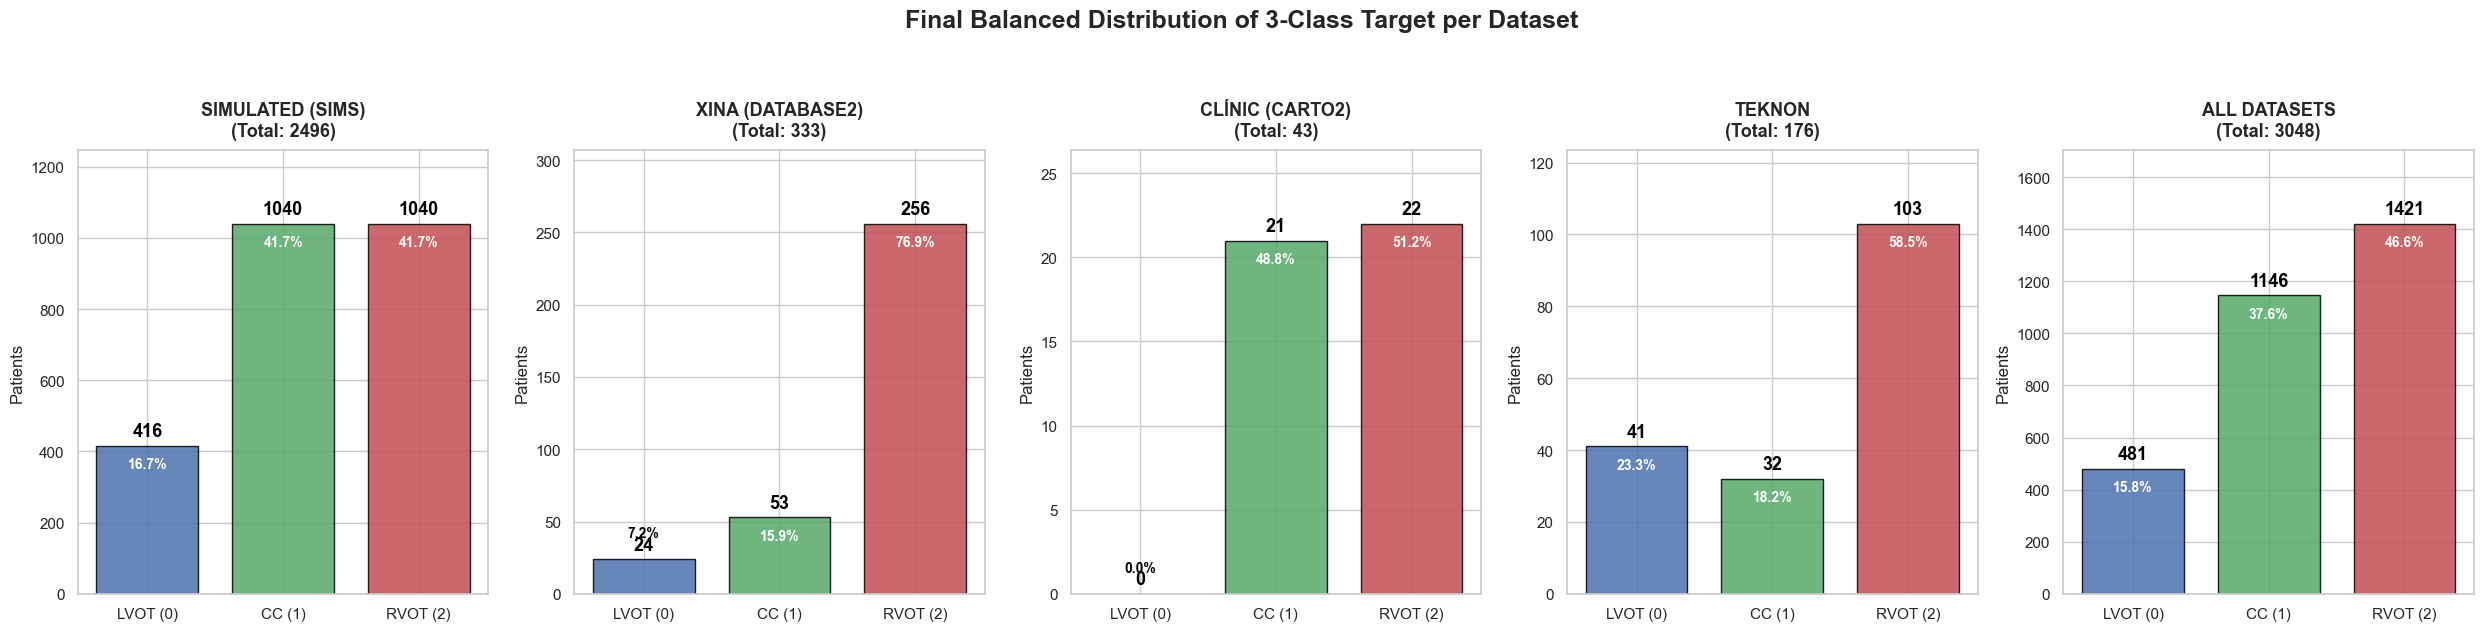

In [31]:

#Map detailed sublocations into distinct macro regions
MAP_7_TO_3 = {
    0: 1,  # LCC -> CC
    1: 1,  # RCC -> CC
    2: 1,  # COMMISSURE -> CC
    3: 0,  # LVOT Subvalvular -> LVOT
    4: 0,  # LVOT Summit -> LVOT
    5: 2,  # RVOT Septum -> RVOT
    6: 2,  # RFW (RVOT Free Wall) -> RVOT
    7: 2   # Generic/Unknown -> RVOT
}

# Transform baseline data targets via list comprehensions to prevent signal omissions
y_3_Sims = np.array([MAP_7_TO_3[val] for val in y_sub_Sims], dtype=np.int64)
y_3_China = np.array([MAP_7_TO_3[val] for val in y_sub_China], dtype=np.int64)
y_3_Carto = np.array([MAP_7_TO_3[val] for val in y_sub_Clinic], dtype=np.int64)

# Apply identical transformation logic to Teknon clinical identifiers when present
y_3_Teknon = np.array([MAP_7_TO_3.get(val, 2) for val in y_tek], dtype=np.int64) if 'y_tek' in locals() else np.array([])

# Reconstruct the tracking container dictionary for subplots visualization
datasets_3_plot = {
    "Simulated (Sims)": y_3_Sims,
    "Xina (Database2)": y_3_China,
    "Clínic (CARTO2)": y_3_Carto, 
    "Teknon": y_3_Teknon,
    "All datasets": np.concatenate([y_3_Sims, y_3_China, y_3_Carto, y_3_Teknon])
}

# INTERNAL METRIC AUDIT LOGGING
print("="*65)
print(" INTERNAL METRIC VERIFICATION: CLASS INTEGRITY WITHOUT DROPS")
print("="*65)

for name, y_data in datasets_3_plot.items():
    vals, counts = np.unique(y_data, return_counts=True)
    counts_dict = dict(zip(vals, counts))
    final_counts = [counts_dict.get(j, 0) for j in range(3)]
    total = sum(final_counts)

    print(f"\n📊 DATASET: {name.upper()} (Total patients: {total})")
    for idx, name_class in enumerate(['LVOT (Esquerra)', 'CC (Arrels/Comissura)', 'RVOT (Dreta)']):
        count_c = final_counts[idx]
        pct_c = (count_c / total * 100) if total > 0 else 0
        print(f"  • {name_class:<25}: {count_c:>4} patients ({pct_c:>5.1f}%)")

# FINAL PLOT VISUALIZATION GENERATION
fig, axes = plt.subplots(1, 5, figsize=(25, 6), sharey=False)
fig.suptitle('Final Balanced Distribution of 3-Class Target per Dataset', fontsize=18, fontweight='bold', y=1.05)

for i, (name, y_data) in enumerate(datasets_3_plot.items()):
    ax = axes[i]

    vals, counts = np.unique(y_data, return_counts=True)
    counts_dict = dict(zip(vals, counts))
    final_counts = [counts_dict.get(j, 0) for j in range(3)]
    total = sum(final_counts)

    # Render standardized vertical tracking bars
    bars = ax.bar(range(3), final_counts, color=colors_3, edgecolor='black', alpha=0.85, width=0.75)

    ax.set_title(f"{name.upper()}\n(Total: {total})", fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('Patients', fontsize=12)
    ax.set_xticks(range(3))
    ax.set_xticklabels(CLASS_LABELS_3, fontsize=11)
    ax.tick_params(axis='both', which='major', labelsize=11)

    max_val = max(final_counts) if max(final_counts) > 0 else 1
    ax.set_ylim(0, max_val * 1.20)

    # Inject descriptive textual overlays directly over the layout bars
    for bar in bars:
        height = bar.get_height()
        percentage = (height / total) * 100 if total > 0 else 0

        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height + (max_val * 0.015),
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=13,
            fontweight='bold',
            color='black'
        )

        if height > (max_val * 0.15):
            text_y_pos = height - (max_val * 0.05)
            text_color = 'white'
        else:
            text_y_pos = height + (max_val * 0.07)
            text_color = 'black'

        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            text_y_pos,
            f'{percentage:.1f}%',
            ha='center',
            va='center',
            fontsize=10,
            fontweight='semibold',
            color=text_color
        )

plt.tight_layout()
os.makedirs('output/plots', exist_ok=True)
plt.show()